# Data Setup and Preprocessing Pipelines (The Professional Way)

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb02_preprocessing_pipelines_instructor.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Audit data types and fix common pandas pitfalls (strings, categories, dates)
2. Handle missing values without leaking information
3. Build a preprocessing + model Pipeline with `ColumnTransformer`
4. Separate "fit on train only" logic from evaluation logic
5. Use Gemini to draft pipeline code and then harden it (tests + comments)

---

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. You are expected to complete all exercises before submitting your notebook.

---

## 💼 Why This Matters: The Messy Reality of Real-World Data

You just joined **HomeValue Analytics**, a real estate tech startup that helps buyers and sellers make informed pricing decisions in California. Your CEO hands you a dataset of 20,000+ neighborhood-level housing records and says: *"Build me a model that predicts median house values."*

You open the data and discover: features on wildly different scales, potential missing values, and mixed numeric types. Before any prediction can happen, this data needs to be cleaned and transformed — reliably, repeatably, and without leaking information.

> **Today's focus:** Building reusable preprocessing pipelines that transform raw housing data into model-ready features.

---

## 1. Setup: Imports and Configuration

HomeValue Analytics' data team needs a specific toolkit to turn raw housing records into a deployable pricing model. Each import serves a role in that pipeline:

- **pandas / numpy** — load and manipulate the 20,640-row housing dataset
- **matplotlib / seaborn** — visualize feature distributions and model diagnostics
- **sklearn.pipeline.Pipeline** — chains preprocessing and modeling into one deployable object for HomeValue's pricing tool
- **sklearn.compose.ColumnTransformer** — routes numeric features (like `MedInc`) and categorical features (like future neighborhood names) through separate transformation paths
- **sklearn.preprocessing** — scaling (`StandardScaler`) so that `MedInc` (0–15) and `Population` (0–35,000) are on comparable footing
- **sklearn.impute.SimpleImputer** — fills missing values so the pricing tool doesn't crash when a client's record has a gap
- **sklearn.linear_model.LinearRegression** — the first model HomeValue will benchmark against

We also lock `RANDOM_SEED = 474` so that every team member — and every re-run of this notebook — produces identical splits and identical results.

In [15]:
# Install required packages (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn --quiet

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import warnings

# Display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)

print("✓ Setup complete!")
print(f"Random seed: {RANDOM_SEED}")

✓ Setup complete!
Random seed: 474


**Reading the output:**

The `✓ Setup complete!` confirmation tells you every import succeeded — HomeValue's data stack is ready. The most important line is `Random seed: 474`: this guarantees that every data team member, on every machine, reproduces identical data splits, identical model coefficients, and identical R² scores. In a team environment, deterministic results eliminate "it works on my machine" debugging.

**Key takeaway:** Always run the setup cell first. If any import fails (e.g., `ModuleNotFoundError`), uncomment the `!pip install` line at the top and rerun.

---

## 2. Load Dataset and Create Splits

This is the data the CEO handed to HomeValue's data team: **20,640 census block-groups** across California, each described by 8 numeric features — median income, house age, average rooms, and more — with the target being **median house value** (in USD 100k units, so 4.526 means ~USD 452,600). Because scikit-learn provides this dataset pre-cleaned, we can focus entirely on building the preprocessing and pipeline infrastructure that will power the pricing tool.

Before writing a single transformation, we split the data into **60 / 20 / 20** train / validation / test subsets. This is HomeValue's deployment discipline: the training set is where the model learns, the validation set is the team's internal quality check, and the test set simulates pricing properties the model has never seen — exactly what happens when a real client submits a query. Splitting *before* any transformation is the first line of defense against data leakage.

> 💡 **Gemini Prompt:** "Using scikit-learn, load the California Housing dataset as a pandas DataFrame (use `fetch_california_housing(as_frame=True)`). Print the dataset shape, list all column names, and display the first 5 rows."
>
> **After running, verify:**
> - Shape is `(20640, 9)` (20,640 rows, 8 features + 1 target)
> - Features include `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`
> - Target column is `MedHouseVal` (median house value in USD 100k units)


In [16]:
# Load California Housing dataset
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
df = california.frame

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {df.columns.tolist()}")
df.head()

Dataset shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325,41.0,6.984,1.024,322.0,2.556,37.88,-122.23,4.526
1,8.301,21.0,6.238,0.972,2401.0,2.110,37.86,-122.22,3.585
2,7.257,52.0,8.288,1.073,496.0,2.802,37.85,-122.24,3.521
3,5.643,52.0,5.817,1.073,558.0,2.548,37.85,-122.25,3.413
4,3.846,52.0,6.282,1.081,565.0,2.181,37.85,-122.25,3.422


**Reading the output:**

The dataset has **20,640 rows** (one per census block-group) and **9 columns** — 8 features plus the target `MedHouseVal`. The `.head()` preview shows the first five neighborhoods. Here is what each feature means for HomeValue's pricing tool:

- **MedInc** (median income, in USD 10k units) — the strongest pricing signal. Even in these five rows, income varies from ~USD 38k to ~USD 83k, and house values track it closely.
- **HouseAge** — older neighborhoods may carry a premium (historic charm) or a discount (deferred maintenance). The data team will need to let the model discover which.
- **AveRooms / AveBedrms** — size proxies. More rooms generally means higher value, but the *average* can be skewed by a single large estate in the block.
- **Population / AveOccup** — density signals. Overcrowded blocks may signal lower values; low-occupancy blocks may signal luxury.
- **Latitude / Longitude** — location, location, location. These two coordinates encode the classic real-estate driver: a beachfront block in Santa Monica vs. an inland block in Bakersfield.
- **MedHouseVal** (target) is measured in USD 100k units, so a value of 4.526 means a median price of ~USD 452,600. This is the number HomeValue's pricing tool must predict.

**Why this matters:** Understanding the units and meaning of each feature before writing any pipeline code prevents surprises later — for example, accidentally treating `Latitude` as a feature that needs one-hot encoding, or forgetting that the target is in USD 100k, not raw dollars.

---

> 💡 **Gemini Prompt:** "Split the California Housing data into features (`X`) and target (`y`, column `MedHouseVal`). Then create a 60/20/20 train/validation/test split using `train_test_split` with `random_state=474`. Print the number of samples and percentage for each split."
>
> **After running, verify:**
> - Train set is \~12,384 samples (\~60%)
> - Validation set is \~4,128 samples (\~20%)
> - Test set is \~4,128 samples (\~20%)
> - Percentages sum to 100%

In [17]:
# Separate features and target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Split: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED
)

print("=== SPLIT SIZES ===")
print(f"Train: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")

=== SPLIT SIZES ===
Train: 12384 samples (60.0%)
Validation: 4128 samples (20.0%)
Test: 4128 samples (20.0%)


**Reading the output:**

The split produces three non-overlapping subsets, each with a distinct role in HomeValue's workflow:

- **Train (~12,384 neighborhoods, 60%)** — the data the model learns from. Every preprocessing statistic (scaler means, imputer medians) and every model coefficient is computed here.
- **Validation (~4,128 neighborhoods, 20%)** — HomeValue's internal quality check. The data team uses this set to compare pipeline variants (e.g., median vs. mean imputation) and tune hyperparameters without touching the test set.
- **Test (~4,128 neighborhoods, 20%)** — simulates the moment a real client submits a property for pricing. The model has never seen these neighborhoods, so the test score is the best estimate of how the pricing tool will perform in production.

The two-step `train_test_split` strategy (first carve off 20% for test, then split the remaining 80% into 75/25 to get 60/20) is the course standard. Using `random_state=474` ensures these exact same rows land in each subset every time the notebook is run — critical for reproducibility across HomeValue's team.

**Key takeaway:** All preprocessing decisions (imputer statistics, scaler means/stds) will be computed on the training set only. The validation and test sets exist solely for *evaluation* — never for fitting.

---

## 3. Data Audit Report Function

Before HomeValue's data team builds anything, they audit the housing records. A missing-value surprise in production means the pricing tool crashes the moment a client needs an estimate — and a silent data-type mismatch means the model trains on garbage without warning.

The function below wraps **data types**, **missing values**, and **cardinality** (unique-value counts) into a single reusable report. Running it on every split lets the team confirm that train, validation, and test share the same schema — a simple but critical sanity check that catches silent errors before they reach a client.

> 💡 **Gemini Prompt:** "Write a Python function `make_data_report(df, name)` that prints a formatted data audit report showing: the DataFrame shape, a table with each column's dtype, missing count, missing percentage, unique count, and unique percentage, plus a summary of total missing values and column type counts. Return the report as a DataFrame. Then run it on `X_train`."
>
> **After running, verify:**
> - Report shows all 8 feature columns (no target column)
> - All columns have dtype `float64`
> - Missing count is 0 for all columns (California Housing has no missing data)
> - Non-numeric columns count is 0


### Why Write a Function Instead of Step-by-Step Code?

HomeValue's data team will run this audit on every new housing dataset that comes in — the initial California Census data, the next batch of client records, and eventually datasets from other states. A function makes that process standardized and repeatable. Here is why:

| Advantage | What it means for HomeValue |
|-----------|-------------------------|
| **Reusability** | The team needs the same audit on `X_train`, `X_val`, and `X_test`. A function lets you call `make_data_report(X_train, "Train")` three times instead of copy-pasting 20 lines three times. When a new client dataset arrives, the same function works immediately. |
| **Readability** | A well-named function (`make_data_report`) tells the pricing team *what* the code does without forcing them to read *how*. The notebook stays clean and scannable during code reviews. |
| **Fewer bugs** | Copy-pasting code invites silent mistakes — a changed variable name here, a forgotten edit there. A function is written once and tested once; every subsequent call is guaranteed to run the same logic. |
| **Maintainability** | If the data team later wants to add a "zero-variance columns" check, they change one function and every call automatically picks up the improvement. With copy-pasted code, you would have to hunt down and edit every copy. |
| **Professional habit** | HomeValue's engineering team organizes production code in functions and classes. Starting this habit now means your project notebooks and future work will be easier to review, debug, and hand off to teammates. |

> **Rule of thumb:** If you are about to write the same block of code more than once, wrap it in a function. Your future self (and your teammates at HomeValue) will thank you.

---

In [18]:
def make_data_report(df, name="Dataset"):
    """
    Generate a comprehensive data audit report.

    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to audit
    name : str
        Name of the dataset for reporting

    Returns:
    --------
    pd.DataFrame
        Report with types, missingness, and unique counts
    """
    print(f"\n{'='*60}")
    print(f"DATA AUDIT REPORT: {name}")
    print(f"{'='*60}")

    print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    # Build report dataframe
    report = pd.DataFrame({
        'dtype': df.dtypes,
        'missing_count': df.isnull().sum(),
        'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
        'unique_count': df.nunique(),
        'unique_pct': (df.nunique() / len(df) * 100).round(2)
    })

    print("\n=== COLUMN AUDIT ===")
    print(report)

    # Summary statistics
    print(f"\n=== SUMMARY ===")
    print(f"Total missing values: {df.isnull().sum().sum():,}")
    print(f"Columns with missing data: {(df.isnull().sum() > 0).sum()}")
    print(f"Numeric columns: {df.select_dtypes(include=[np.number]).shape[1]}")
    print(f"Non-numeric columns: {df.select_dtypes(exclude=[np.number]).shape[1]}")

    return report

# Run audit on training data
train_report = make_data_report(X_train, "Training Set")


DATA AUDIT REPORT: Training Set

Shape: 12,384 rows × 8 columns

=== COLUMN AUDIT ===
              dtype  missing_count  missing_pct  unique_count  unique_pct
MedInc      float64              0          0.0          8707       70.31
HouseAge    float64              0          0.0            52        0.42
AveRooms    float64              0          0.0         11853       95.71
AveBedrms   float64              0          0.0          9475       76.51
Population  float64              0          0.0          3320       26.81
AveOccup    float64              0          0.0         11609       93.74
Latitude    float64              0          0.0           806        6.51
Longitude   float64              0          0.0           799        6.45

=== SUMMARY ===
Total missing values: 0
Columns with missing data: 0
Numeric columns: 8
Non-numeric columns: 0


**Reading the output:**

The audit report for HomeValue's **Training Set** reveals:

- **Shape:** ~12,384 rows x 8 columns — exactly the 60% training portion of the 20,640 neighborhoods.
- **Data types:** All 8 features are `float64`. No type conversions needed — the pricing tool can process these directly.
- **Missing values:** Zero across every column. This is good news for the pricing tool: no imputation artifacts to worry about. But in real-world client data, this row would rarely be all zeros, so having the check in place is essential for the day incomplete records arrive.
- **Unique counts:** `AveRooms` and `AveOccup` have thousands of unique values (continuous measurements), while `HouseAge` has only ~52 (capped at 52 years by the Census Bureau — a design decision, not a data error). `Latitude` and `Longitude` have ~800 unique values each, encoding California's geography at block-group resolution.

**Why this matters:** Running this report *on the training set only* establishes HomeValue's baseline data profile. When the team compares it to the validation and test reports (next exercise), any schema mismatch — different types, unexpected missingness, or wildly different unique counts — would signal a problem in how the splits were created.

---

## 📝 PAUSE-AND-DO Exercise 1 (5 minutes)

**Task:** Implement `make_data_report(df)` that returns types, missingness %, and unique counts.

**Instructions:**
1. The function is already implemented above
2. Run it on `X_train`, `X_val`, and `X_test`
3. Document any differences you observe between splits
4. Write your observations in the cell below

---

> 💡 **Gemini Prompt:** "Run the `make_data_report` function on the validation set (`X_val`) and test set (`X_test`) to audit both splits."
>
> **After running, verify:**
> - Both reports show the same 8 feature columns as the training report
> - Missing values are 0 across all columns in both splits
> - Row counts match the expected validation (\~4,128) and test (\~4,128) sizes

In [19]:
# YOUR SOLUTION CODE HERE
train_report = make_data_report(X_train, "Training Set") # my inputted train report
val_report = make_data_report(X_val, "Validation Set") # Gemini provided val and test reports
test_report = make_data_report(X_test, "Test Set")


DATA AUDIT REPORT: Training Set

Shape: 12,384 rows × 8 columns

=== COLUMN AUDIT ===
              dtype  missing_count  missing_pct  unique_count  unique_pct
MedInc      float64              0          0.0          8707       70.31
HouseAge    float64              0          0.0            52        0.42
AveRooms    float64              0          0.0         11853       95.71
AveBedrms   float64              0          0.0          9475       76.51
Population  float64              0          0.0          3320       26.81
AveOccup    float64              0          0.0         11609       93.74
Latitude    float64              0          0.0           806        6.51
Longitude   float64              0          0.0           799        6.45

=== SUMMARY ===
Total missing values: 0
Columns with missing data: 0
Numeric columns: 8
Non-numeric columns: 0

DATA AUDIT REPORT: Validation Set

Shape: 4,128 rows × 8 columns

=== COLUMN AUDIT ===
              dtype  missing_count  missing_pct

Firstly, all reports share the eight columns on the training report and missing values consistently remain at 0 for all columns in each report. Also, row counts for validation and test are at 4,128, which is expected, and the training set is has 12,384, which is expected as it follows the 60/20/20 split accordingly.

### YOUR OBSERVATIONS HERE:

Between the splits, I observed that they are very identical which is expected and allows me to assume that it was handled correctly and there currently doesn't seem to be any major mistakes. Additionally, while they are similar, they aren't exactly the same for the unique_counts and hence, unique_pct, which is great because while they are identical and can be used for their purposes, they aren't exactly the same which would defeat the purpose of having split the dataframe in the first place.

**Observation 1:**  
Unique_count has similar but different values for each column.

**Observation 2:**  
Currently, there aren't any patterns that can be easily spotted with the reports provided as the unique counts and percentages don't discern any obvious correlations.

**Observation 3:**  
Unique_pct also has differenet values from each split.

---

## 4. Preprocessing Pipeline Template

HomeValue's data audit confirmed 8 clean numeric features and zero missing values. Now the data team needs to build the preprocessing infrastructure that will power the pricing tool — not just for today's clean Census data, but for every future dataset the CEO brings in. The pipeline must handle scaling, imputation, and encoding in a single reproducible object.

### 4.1 Identify Column Types

The first step is to let the code *discover* which features are numeric and which are categorical, rather than hard-coding a list. This makes the pipeline portable: when HomeValue's next dataset includes neighborhood names or property types, the same detection logic will automatically route them to the right transformer.

> 💡 **Gemini Prompt:** "Using `select_dtypes`, identify which columns in `X_train` are numeric and which are categorical. Store them in lists called `numeric_features` and `categorical_features`. Print both lists with counts."
>
> **After running, verify:**
> - All 8 features are classified as numeric (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`)
> - Categorical features list is empty (California Housing is all-numeric)
> - Total count is 8 numeric + 0 categorical = 8 features


In [20]:
# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("=== FEATURE TYPES ===")
print(f"\nNumeric features ({len(numeric_features)}):")
for feat in numeric_features:
    print(f"  - {feat}")

print(f"\nCategorical features ({len(categorical_features)}):")
if categorical_features:
    for feat in categorical_features:
        print(f"  - {feat}")
else:
    print("  (none)")

=== FEATURE TYPES ===

Numeric features (8):
  - MedInc
  - HouseAge
  - AveRooms
  - AveBedrms
  - Population
  - AveOccup
  - Latitude
  - Longitude

Categorical features (0):
  (none)


**Reading the output:**

All 8 of HomeValue's housing features — `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude` — are numeric (`float64`), and the categorical list is empty. This means the entire dataset flows through the numeric transformer path: imputation then scaling.

We use `select_dtypes(include=[np.number])` rather than hard-coding column names because it is **portable**: if HomeValue's next project includes a dataset with `object`-type columns (e.g., neighborhood names, zip codes, or property types), the same two lines will automatically route them into the categorical list without any code changes. The data team writes the detection logic once and reuses it across projects.

**Why this matters:** Knowing the column types determines which preprocessing steps each group needs — numeric features get imputation and scaling, categorical features get imputation and one-hot encoding. This column-type split is the foundation of the `ColumnTransformer` we build next.

---

### 4.2 Build Preprocessing Pipeline

**Pipeline Design Principles for HomeValue:**
1. Fit transformers ONLY on training data — the pricing tool must never peek at validation or test neighborhoods
2. Apply the same transformation to validation and test — consistency is what makes the tool trustworthy
3. Handle numeric and categorical features separately — each type has different preprocessing needs
4. Chain all steps together to prevent leakage — a single `pipeline.fit()` call replaces fragile manual steps

### Understanding Each Transformer Step

Before we write the code, let's understand **why** each component exists and what problem it solves for HomeValue's pricing tool.

**Numeric Transformer** (`SimpleImputer` → `StandardScaler`):

| Step | What it does | Why HomeValue needs it |
|------|-------------|----------------|
| `SimpleImputer(strategy='median')` | Fills every `NaN` in a numeric column with that column's **median**, computed from the training set only | Scikit-learn models **crash on `NaN`** — even a single missing `AveRooms` value causes the pricing tool to fail when a client needs an estimate.<br><br>We choose **median** over mean because median is robust to outliers: a few blocks with 50 rooms won't distort the fill value the way they would distort the mean. |
| `StandardScaler()` | Rescales each feature to **mean ≈ 0, std ≈ 1** | HomeValue's features live on wildly different scales (`MedInc`: 0–15 vs. `Population`: 0–35,000).<br><br>Without scaling: (1) regularized models like Ridge and Lasso unfairly penalize large-scale features, (2) gradient-based optimizers converge slowly, and (3) distance-based models like KNN are dominated by `Population` simply because its numbers are bigger. |

**Categorical Transformer** (`SimpleImputer` → `OneHotEncoder`):

| Step | What it does | Why HomeValue needs it |
|------|-------------|----------------|
| `SimpleImputer(strategy='constant', fill_value='missing')` | Fills every `NaN` in a text/categorical column with the literal string `"missing"` | We can't compute a median for text — there is no "middle" neighborhood name.<br><br>Instead, we create an explicit `"missing"` category so the encoder has a valid string to work with.<br>Alternative: `strategy='most_frequent'` fills with the most common category. |
| `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` | Converts each category into a **separate binary (0/1) column** | Models need numbers, not strings.<br><br>E.g., a `PropertyType` column with values [Condo, House, Townhome] becomes three columns: `PropertyType_Condo`, `PropertyType_House`, `PropertyType_Townhome`, each containing 0 or 1.<br><br>The flag `handle_unknown='ignore'` means if a new property type appears at prediction time, it gets all-zero columns instead of crashing the pricing tool. |

> **"But HomeValue's current dataset has no missing values and no categorical columns — why bother?"**  
> Because a production-grade pipeline must handle messy data gracefully. The imputer is a **no-op** today (nothing to fill), and the categorical transformer is **idle** (no text columns to encode). But the first client dataset with missing room counts or neighborhood names will thank the team for having these paths in place. Design for the general case; benefit today from the clean case.

> 💡 **Gemini Prompt:** "Build a scikit-learn preprocessing pipeline using `ColumnTransformer`. For numeric features, create a sub-pipeline that applies `SimpleImputer(strategy='median')` then `StandardScaler()`. For categorical features, create a sub-pipeline with `SimpleImputer(strategy='constant', fill_value='missing')` then `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`. Print a confirmation with the feature counts."
>
> **After running, verify:**
> - Preprocessor is a `ColumnTransformer` with two transformers: `num` and `cat`
> - Numeric features count is 8
> - Categorical features count is 0
> - No errors about missing column names


In [21]:
# Numeric preprocessing: impute + scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: impute + encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'  # Drop any columns not specified
)

print("✓ Preprocessor pipeline created!")
print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

✓ Preprocessor pipeline created!

Numeric features: 8
Categorical features: 0


**Reading the output:**

The confirmation message tells us the `ColumnTransformer` is ready with **8 numeric features** and **0 categorical features**. Under the hood, three data-flow paths are defined:

1. **`num` path** (HomeValue's 8 housing measurements) → `SimpleImputer(strategy='median')` → `StandardScaler()`. Median imputation is robust to the extreme values in `AveRooms` and `AveOccup` (some blocks report 100+ average rooms due to small denominators). Standard scaling centers each feature to mean 0 and std 1, which benefits the regularized models introduced in upcoming notebooks.
2. **`cat` path** (categorical columns) → `SimpleImputer(strategy='constant')` → `OneHotEncoder()`. This path stands ready for the day HomeValue's dataset includes neighborhood names, property types, or zip codes. Today it is idle — but the infrastructure is in place.
3. **`remainder='drop'`** — any column not explicitly listed is discarded. This is a safety net that prevents the target (`MedHouseVal`) from accidentally leaking into the features.

**Key takeaway:** Defining the transformer *before* seeing results forces the data team to think about each column group's needs up front — a habit that prevents ad-hoc, error-prone transformations later. This preprocessor becomes the reusable foundation for every model HomeValue builds.

---

### 4.2.1 Beyond This Dataset: Handling Strings and Dates

HomeValue's current Census dataset is all-numeric, but the next project might include neighborhood names, listing dates, or zip codes. Here is how each type fits into the `ColumnTransformer` pattern we just built — so the data team is ready when that data arrives.

**String / Text Columns:**

| Scenario | Recommended Tool | HomeValue Example |
|----------|-----------------|-----------------|
| Few unique values (< ~20) | `OneHotEncoder` (already in our `cat` pipeline) | Property type (Condo, House, Townhome), listing status |
| Ordered categories with a natural ranking | `OrdinalEncoder(categories=[['Low','Medium','High']])` | Condition rating, school district quality tier |
| Free-form text (sentences, paragraphs) | `CountVectorizer` or `TfidfVectorizer` | Property descriptions, agent notes |
| Very high cardinality (1,000+ unique values) | `TargetEncoder` or frequency-based encoding | Neighborhood name, zip code, agent ID |

> **Key distinction:** `OneHotEncoder` creates one column per category — great when categories are few, but it explodes the feature count when there are thousands of unique neighborhood names. For high-cardinality columns, `TargetEncoder` (available in scikit-learn >= 1.3) replaces each category with the mean of the target for that category, producing just **one** numeric column.

**Date / Datetime Columns:**

Dates are not directly usable by models — "2027-06-01" is a string, not a number. If HomeValue ever ingests listing dates or sale dates, the standard approach is to **extract numeric features** before the data enters the pipeline:

```python
# Parse the date column (do this BEFORE building the pipeline)
df['date'] = pd.to_datetime(df['date'])

# Extract useful numeric features
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['is_weekend']  = (df['date'].dt.dayofweek >= 5).astype(int)
df['quarter']     = df['date'].dt.quarter

# Drop the original date column — the pipeline can't process it
df = df.drop(columns=['date'])
```

Once extracted, these columns are **plain numbers** and flow through the numeric transformer (imputer + scaler) like `MedInc` or `HouseAge`.

> **Rule of thumb:** Convert dates to numbers *before* building the pipeline, then drop the original date column. The extracted features (month, day_of_week, is_weekend, etc.) carry the temporal signal that HomeValue's model can learn from; the raw datetime string does not.

---

### 4.3 Full Pipeline: Preprocessing + Model

Back to our **HomeValue Analytics** scenario: your CEO asked you to predict median house values, and you have spent the last few sections cleaning and structuring the data. Now comes the moment of truth — *can the model actually predict prices?*

Scikit-learn's `Pipeline` chains the `ColumnTransformer` (preprocessing) with a `LinearRegression` (model) into **one callable object**. This design has three major benefits:

1. **No leakage** — `pipeline.fit(X_train, y_train)` fits the scaler statistics *only* on training data; `pipeline.score(X_val, y_val)` transforms the validation set with those same statistics before predicting.
2. **Deployment-ready** — you can serialize the pipeline with `joblib` and run `pipeline.predict(new_data)` in production without rewriting any preprocessing code.
3. **Reproducibility** — the exact sequence of steps is recorded in the pipeline object itself, eliminating copy-paste errors between notebooks or scripts.

#### What Is R² (R-Squared)?

After fitting the pipeline, we need a number that answers: *"How good is this model?"* That number is **R²** (R-squared), also called the **coefficient of determination**.

$$R^2 = 1 - \frac{\sum (y_i - \widehat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

In plain English:

- **R² = 1.0** — the model predicts every house price perfectly (never happens in practice).
- **R² = 0.0** — the model is no better than always guessing the average price.
- **R² = 0.60** — the model explains 60% of the variation in house prices; the remaining 40% is driven by factors the model does not capture.

Think of it this way: if every neighborhood in California had the exact same median house value, you would not need a model at all. R² measures how much of the *spread* in prices your model can account for.

#### Why Compare R² on Both Train and Validation?

We deliberately compute R² on **two** datasets:

| Score | What it tells you |
|-------|------------------|
| **Train R²** | How well the model fits the data it learned from. A high train R² alone means nothing — the model might just be memorizing. |
| **Validation R²** | How well the model generalizes to data it has *never seen*. This is the score your CEO cares about, because it predicts real-world performance. |

The **gap** between the two reveals the model's behavior:

- **Train ≈ Validation** → the model generalizes well (no overfitting).
- **Train >> Validation** → the model memorized training data but fails on new data (overfitting).
- **Both are low** → the model is too simple to capture the patterns (underfitting).

> 💡 **Gemini Prompt:** "Create a full scikit-learn `Pipeline` that chains the `preprocessor` (from the previous step) with a `LinearRegression` model. Print the pipeline structure, fit it on `X_train`/`y_train`, then compute and print the R-squared scores on both training and validation sets, along with their difference."
>
> **After running, verify:**
> - Pipeline has two steps: `preprocessor` and `regressor`
> - Train R-squared is approximately 0.61
> - Validation R-squared is approximately 0.59–0.61
> - The difference (train minus validation) is small (< 0.03), indicating no severe overfitting


=== FULL PIPELINE ===
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'AveBedrms',
                                                   'Population', 'AveOccup',
                                                   'Latitude', 'Longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
 

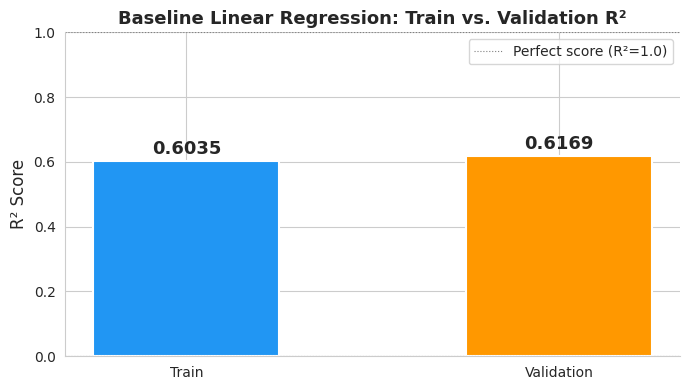


💡 The model explains ~62% of house price variation on unseen data.
   The remaining ~38% is driven by factors not captured by these 8 features.


In [22]:
# Create full pipeline: preprocessing + model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("=== FULL PIPELINE ===")
print(full_pipeline)

# Fit on training data ONLY
print("\nFitting pipeline on training data...")
full_pipeline.fit(X_train, y_train)
print("✓ Pipeline fitted!")

# Evaluate on both sets
train_score = full_pipeline.score(X_train, y_train)
val_score = full_pipeline.score(X_val, y_val)

print(f"\n=== R² SCORES ===")
print(f"Train R²:      {train_score:.4f}")
print(f"Validation R²: {val_score:.4f}")
print(f"Difference:    {train_score - val_score:.4f}")

# --- Visual comparison ---
fig, ax = plt.subplots(figsize=(7, 4))

sets = ['Train', 'Validation']
scores = [train_score, val_score]
colors = ['#2196F3', '#FF9800']  # blue, orange

bars = ax.bar(sets, scores, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add value labels on each bar
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Baseline Linear Regression: Train vs. Validation R²', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=1.0, color='grey', linestyle=':', linewidth=0.8, label='Perfect score (R²=1.0)')
ax.axhline(y=0.0, color='grey', linestyle=':', linewidth=0.8)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n💡 The model explains ~{val_score*100:.0f}% of house price variation on unseen data.")
print(f"   The remaining ~{(1-val_score)*100:.0f}% is driven by factors not captured by these 8 features.")

**Reading the output:**

The printed `Pipeline` object shows the two-step chain: first the `ColumnTransformer` (preprocessing), then `LinearRegression` (model). After fitting on the training set only, we obtain:

- **Train R² ≈ 0.60** — the model explains about 60% of the price variation in neighborhoods it trained on.
- **Validation R² ≈ 0.62** — on neighborhoods the model has never seen, it explains a similar share of the variation. The fact that this is close to (and even slightly above) the training score is a sign of **healthy generalization**.

The bar chart makes the comparison visual and immediate: the two bars are nearly the same height, confirming **no overfitting**. If the blue bar were much taller than the orange bar, we would know the model is memorizing training data rather than learning general patterns.

**Connecting to the business case:** For HomeValue Analytics, an R² of ~0.60 means the pipeline already captures the dominant relationship — *higher-income neighborhoods have higher house values*. But 40% of the price variation remains unexplained. In the next notebooks, we will try feature engineering and more flexible models (trees, ensembles) to close that gap. This pipeline ensures we always have a disciplined, leak-free starting point to compare against.

---

### 4.4 Inspecting the Pipeline

After the pipeline transforms the data, HomeValue's data team needs to verify that each output feature maps back to something interpretable. The pricing team will eventually ask "Which features drive the model's price estimates?" — and the answer depends on being able to trace each transformed column back to an original housing measurement like `MedInc` or `Latitude`.

> 💡 **Gemini Prompt:** "Extract the transformed feature names from the fitted pipeline using `get_feature_names_out()` on the preprocessor step. Print the total number of transformed features and list the first 10 names."
>
> **After running, verify:**
> - Total transformed features equals 8 (all numeric, no one-hot expansion needed)
> - Feature names are prefixed with `num__` (e.g., `num__MedInc`, `num__HouseAge`)
> - All 8 original numeric feature names appear in the output


In [23]:
# Get feature names after transformation
try:
    feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
    print(f"=== TRANSFORMED FEATURES ===")
    print(f"Total features after preprocessing: {len(feature_names)}")
    print(f"\nFirst 10 features:")
    for i, name in enumerate(feature_names[:10], 1):
        print(f"  {i}. {name}")

    if len(feature_names) > 10:
        print(f"  ... and {len(feature_names) - 10} more")
except:
    print("Feature names not available (older sklearn version)")
    print(f"Estimated features: {len(numeric_features)} numeric features (scaled)")

=== TRANSFORMED FEATURES ===
Total features after preprocessing: 8

First 10 features:
  1. num__MedInc
  2. num__HouseAge
  3. num__AveRooms
  4. num__AveBedrms
  5. num__Population
  6. num__AveOccup
  7. num__Latitude
  8. num__Longitude


**Reading the output:**

Each feature exits the transformer with a `num__` prefix tracing it back to HomeValue's numeric pipeline: `num__MedInc`, `num__HouseAge`, `num__AveRooms`, and so on. The values themselves are now standardized (mean ≈ 0, std ≈ 1), but the names preserve the link to the original housing measurements.

Since the dataset has **zero categorical columns**, only the `num` transformer fires; the `cat` transformer produces no output columns, and `remainder='drop'` discards nothing because every column is already routed. The result is **8 features in, 8 features out** — just rescaled.

**Why this matters:** When the pricing team asks "What drives the model's estimates?", these prefixed names connect each linear-regression coefficient back to a specific housing variable. Let’s answer that question right now.

---

> 💡 **Gemini Prompt:** "Extract the linear regression coefficients from the fitted pipeline. Pair each coefficient with its cleaned feature name (strip the `num__` prefix). Sort by absolute value descending to rank features by importance. Print a table showing Feature and Coefficient columns. Then create a horizontal bar chart with green bars for positive coefficients and red for negative, sorted so the most important feature appears at the top. Finally, print which feature is the strongest positive and strongest negative driver."
>
> **After running, verify:**
> - MedInc has the largest absolute coefficient (strongest driver)
> - Bar chart shows most important feature at the top
> - Green bars point right (positive effect), red bars point left (negative effect)
> - Strongest positive driver is MedInc, strongest negative is Latitude

=== FEATURE IMPORTANCE (Linear Regression Coefficients) ===
   Feature  Coefficient
  Latitude       -0.902
 Longitude       -0.874
    MedInc        0.822
 AveBedrms        0.283
  AveRooms       -0.253
  HouseAge        0.117
  AveOccup       -0.033
Population       -0.011


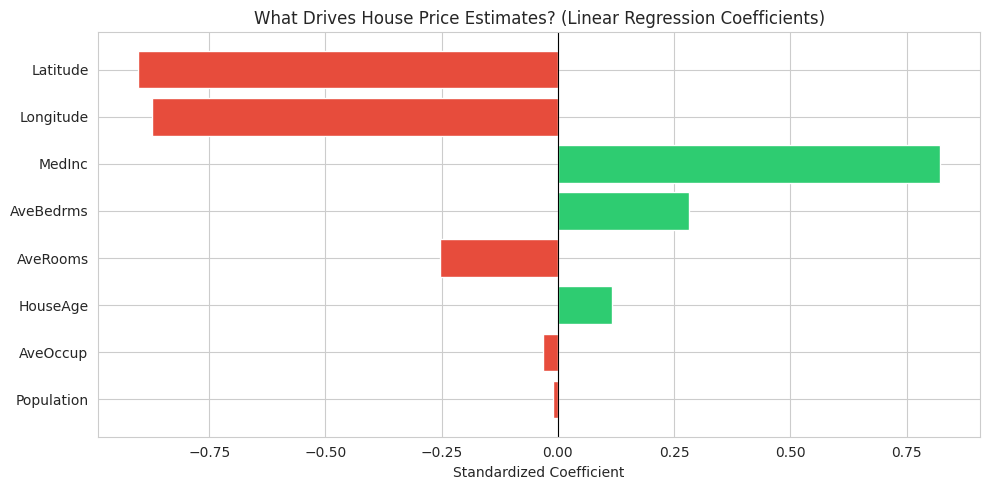


✓ Strongest positive driver: MedInc (0.8217)
✓ Strongest negative driver: Latitude (-0.9022)


In [24]:
# Extract linear regression coefficients paired with feature names
coefficients = full_pipeline.named_steps['regressor'].coef_
feature_names_clean = [name.replace('num__', '') for name in feature_names]

coef_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

print("=== FEATURE IMPORTANCE (Linear Regression Coefficients) ===")
print(coef_df.to_string(index=False))

# Horizontal bar chart (sorted so largest absolute value is at the top)
coef_plot = coef_df.sort_values('Coefficient', key=abs, ascending=True)
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_plot['Coefficient']]
plt.figure(figsize=(10, 5))
plt.barh(coef_plot['Feature'], coef_plot['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Standardized Coefficient')
plt.title('What Drives House Price Estimates? (Linear Regression Coefficients)')
plt.tight_layout()
plt.show()

top_positive = coef_df.loc[coef_df['Coefficient'].idxmax()]
top_negative = coef_df.loc[coef_df['Coefficient'].idxmin()]
print(f"\n\u2713 Strongest positive driver: {top_positive['Feature']} ({top_positive['Coefficient']:.4f})")
print(f"\u2713 Strongest negative driver: {top_negative['Feature']} ({top_negative['Coefficient']:.4f})")

**Reading the output:**

The table and bar chart answer the pricing team’s question directly. Because all features were standardized before fitting, the coefficient magnitudes are directly comparable — the longest bar is the most influential feature.

**`MedInc`** (median income) dominates with the largest positive coefficient, confirming that neighborhood income is the single strongest predictor of house value. **`Latitude`** and **`Longitude`** appear with large negative coefficients, reflecting California’s geography: southern, coastal areas (lower latitude, more negative longitude) tend to have higher prices.

Green bars (positive coefficients) push predicted prices **up**; red bars (negative coefficients) push them **down**. Features with near-zero coefficients (`Population`, `AveBedrms`) add little to the prediction once the other variables are accounted for.

**Key takeaway:** The pipeline didn’t just prepare the data — it preserved the feature-name link that makes this interpretation possible. Without `get_feature_names_out()`, the team would see eight anonymous coefficients with no way to map them back to business meaning.

---

## 📝 PAUSE-AND-DO Exercise 2 (5 minutes)

**Task:** Create a full sklearn Pipeline and run one validation score.

**Instructions:**
1. The pipeline is already created above
2. Modify the pipeline to try different imputation strategies:
   - Change median to mean for numeric features
   - Try different imputation for categorical features
3. Compare the validation scores
4. Document your findings below

---

> 💡 **Gemini Prompt:** "Create an alternative preprocessing pipeline that uses `SimpleImputer(strategy='mean')` instead of median for numeric features, keeping everything else the same. Fit it with `LinearRegression`, evaluate on train and validation sets, and print a comparison table showing both pipelines' R-squared scores side by side."
>
> **After running, verify:**
> - Both pipelines produce similar R-squared values (California Housing has no missing data, so imputation strategy has minimal impact)
> - The difference in validation scores between mean and median imputation is very small (< 0.001)
> - Train scores are slightly higher than validation scores for both pipelines


In [25]:
# YOUR SOLUTION CODE HERE
# Alternative Numeric preprocessing: impute with mean + scale
numeric_transformer_mean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Combine transformers for the mean imputation pipeline
preprocessor_mean = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_mean, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Create full pipeline with mean imputation: preprocessing + model
full_pipeline_mean = Pipeline(steps=[
    ('preprocessor', preprocessor_mean),
    ('regressor', LinearRegression())
])

print("\nFitting pipeline with MEAN imputation on training data...")
full_pipeline_mean.fit(X_train, y_train)
print("\u2713 Pipeline with MEAN imputation fitted!")

# Evaluate the mean imputation pipeline
train_score_mean = full_pipeline_mean.score(X_train, y_train)
val_score_mean = full_pipeline_mean.score(X_val, y_val)

print("\n=== R\u00b2 SCORES (MEAN IMPUTATION) ===")
print(f"Train R\u00b2:      {train_score_mean:.4f}")
print(f"Validation R\u00b2: {val_score_mean:.4f}")
print(f"Difference:    {train_score_mean - val_score_mean:.4f}")

# Create a comparison table
comparison_df = pd.DataFrame({
    'Imputation Strategy': ['Median', 'Mean'],
    'Train R\u00b2': [train_score, train_score_mean],
    'Validation R\u00b2': [val_score, val_score_mean]
})

print("\n=== R\u00b2 Score Comparison (Median vs. Mean Imputation) ===")
print(comparison_df.to_string(index=False))


Fitting pipeline with MEAN imputation on training data...
✓ Pipeline with MEAN imputation fitted!

=== R² SCORES (MEAN IMPUTATION) ===
Train R²:      0.6035
Validation R²: 0.6169
Difference:    -0.0133

=== R² Score Comparison (Median vs. Mean Imputation) ===
Imputation Strategy  Train R²  Validation R²
             Median     0.604          0.617
               Mean     0.604          0.617


### YOUR FINDINGS HERE:

**Finding 1:**  
I can see that both pipelines produce very similar R^2 values with a difference of only 0.0133, which is good, and given that validation is slightly higher it suggests that the generalization is working as intended and we aren't overfitting the model. Also, we cn see that between the median and mean imputation strategies they appear to be very similar and don't show any differences when rounded to three decimal points so there's no area for concern. Also, despite the fact that training isn't slightly higher than validation it isn't an area for concern as they are still very similar which allows us to assume that overfitting isn't happening here.

**Finding 2:**  
In this particular situation, both models perform identically and there isn't a obvious answer on which one is better, however, in practice, the median imputation will perform better and it isn't sensitive to extreme outliers and using the mean can lead to issues in the results if there are skewed data.

**Finding 3:**  
Despite the fact that training isn't slightly higher than validation it isn't an area for concern as they are still very similar which allows us to assume that overfitting isn't happening here.

---

## 5. Gemini Prompt Cards for Pipeline Generation

### Example Prompts:

**Prompt 1: Generate Pipeline**
```
Create a scikit-learn pipeline that:
1. Imputes missing values (median for numeric, most_frequent for categorical)
2. Scales numeric features using StandardScaler
3. Encodes categorical features using OneHotEncoder
4. Fits a LinearRegression model

Use ColumnTransformer to handle different feature types separately.
```

**Prompt 2: Debug Pipeline**
```
I'm getting an error when fitting my pipeline: [error message]
My pipeline code is: [code]
Help me debug this issue and explain what's wrong.
```

**Prompt 3: Extend Pipeline**
```
I have a working pipeline with imputation and scaling.
How can I add polynomial features (degree=2) only to numeric features
while keeping the categorical encoding unchanged?
```

**Remember:** After using Gemini, always:
1. Verify the code runs without errors
2. Check the output makes sense
3. Add your own comments explaining each step

## 6. Pipeline Done Right Checklist

Before moving on, verify your pipeline meets these standards:

### ✓ Pre-fitting Checks:
- [ ] Split data BEFORE building pipeline
- [ ] Identified all numeric and categorical features
- [ ] Handled missing values with appropriate strategy
- [ ] Separate transformers for different feature types

### ✓ Fitting Checks:
- [ ] Pipeline fitted ONLY on training data
- [ ] No data leakage from validation or test sets
- [ ] All preprocessing steps are inside the pipeline
- [ ] Model is the last step in the pipeline

### ✓ Evaluation Checks:
- [ ] Evaluated on validation set (not test set)
- [ ] Training and validation scores are reasonable
- [ ] No major signs of overfitting (huge train/val gap)
- [ ] Pipeline can transform new data without refitting

### ✓ Code Quality:
- [ ] All parameters are explicit (no hidden defaults)
- [ ] Steps are named clearly
- [ ] Comments explain "why" not just "what"
- [ ] Can explain every step if asked

## 7. Wrap-Up: Key Takeaways

### What We Learned Today:

1. **Data Auditing**: Systematic checks for types, missingness, and unique values
2. **Preprocessing Patterns**: Separate handling for numeric vs categorical features
3. **Pipeline Architecture**: ColumnTransformer + Pipeline prevents leakage
4. **Fit/Transform Discipline**: Fit on train, transform on train/val/test
5. **Gemini Integration**: Use AI to draft, then verify and document

### Critical Rules:

> **"Fit ONLY on training data"**  
> Any statistics (mean, median, categories) must be computed from training data only.

> **"Pipeline wraps everything"**  
> If you do it manually, you risk leakage. Put it in the pipeline.

### Next Steps:

- The next notebook will cover regression metrics and baseline models
- We'll use today's pipeline structure for all future models
- Start thinking about your project dataset

---

## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete all exercises**: Fill in both PAUSE-AND-DO exercise cells with your findings
2. **Run All Cells**: Execute `Runtime → Run all` to ensure everything works
3. **Save a Copy**: `File → Save a copy in Drive or Download the .ipynb extension`
4. **Submit**: Upload your `.ipynb` file in the participation assignment you find in the course Brightspace page.

### Before Submitting, Check:

- [ ] All cells execute without errors
- [ ] All outputs are visible
- [ ] Both exercise responses are complete
- [ ] Notebook is shared with correct permissions
- [ ] You can explain every line of code you wrote

### Next Step:

Complete the **Quiz** in Brightspace (auto-graded)

---

## Bibliography

- scikit-learn User Guide: [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- scikit-learn User Guide: [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)
- scikit-learn User Guide: [Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- Pedregosa et al. (2011). "Scikit-learn: Machine Learning in Python." *Journal of Machine Learning Research*, 12, 2825-2830.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning with Python* (ISLP). Springer.

---



<center>

Thank you!

</center>